<a href="https://colab.research.google.com/github/ClassNeuralNetwork/classification-fatigue-detection/blob/main/Deteccao_Sonolencia_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importando dependências necessárias

In [46]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import ConvNeXtLarge
from tensorflow.keras import layers, Model, regularizers
import kagglehub
import shap

Carregando dataset

In [2]:
path = kagglehub.dataset_download("serenaraju/yawn-eye-dataset-new")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'yawn-eye-dataset-new' dataset.
Path to dataset files: /kaggle/input/yawn-eye-dataset-new


In [3]:
path = "/kaggle/input/yawn-eye-dataset-new"

for item in os.listdir(path):
    print(item)

dataset_new


In [4]:
BASE = "/kaggle/input/yawn-eye-dataset-new/dataset_new"

train_dir = os.path.join(BASE, "train")
test_dir  = os.path.join(BASE, "test")

print(train_dir)
print(test_dir)

CLASSES = sorted(os.listdir(train_dir))
NUM_CLASSES = len(CLASSES)
print("Classes:", CLASSES)

/kaggle/input/yawn-eye-dataset-new/dataset_new/train
/kaggle/input/yawn-eye-dataset-new/dataset_new/test
Classes: ['Closed', 'Open', 'no_yawn', 'yawn']


In [5]:
IMAGE_SIZE = 256

def carregar_dataset_np(root):
    imagens = []
    rotulos = []

    for label, cls in enumerate(CLASSES):
        cls_path = os.path.join(root, cls)

        for fname in os.listdir(cls_path):
            if fname.lower().endswith(("jpg","png","jpeg")):
                img_path = os.path.join(cls_path, fname)

                img = Image.open(img_path).convert("RGB")
                img = img.resize((IMAGE_SIZE, IMAGE_SIZE))

                img = np.array(img, dtype=np.float32) / 255.0

                imagens.append(img)
                rotulos.append(label)

    return np.array(imagens), np.array(rotulos)

Treinando dataset

In [6]:
X_train, y_train = carregar_dataset_np(train_dir)
X_test,  y_test  = carregar_dataset_np(test_dir)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (2467, 256, 256, 3) (2467,)
Test: (433, 256, 256, 3) (433,)


In [7]:
BATCH = 32

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_ds  = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_ds = train_ds.shuffle(2000).batch(BATCH).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

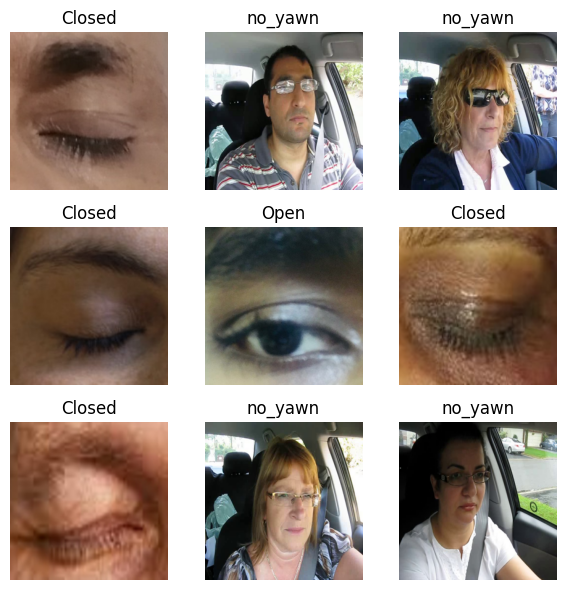

In [8]:
plt.figure(figsize=(6,6))
for i, (img, label) in enumerate(train_ds.unbatch().take(9)):
    plt.subplot(3,3,i+1)
    plt.imshow(img.numpy())
    plt.title(CLASSES[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:

modelo = keras.Sequential([
    keras.Input(shape = (IMAGE_SIZE, IMAGE_SIZE, 3)),
    layers.Conv2D(32, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 246016)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │       984,068 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,003,460 (3.83 MB)

 Trainable params: 1,003,460 (3.83 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stopping = EarlyStopping(monitor='val_loss', patience=15, mode='min', restore_best_weights=True)

In [11]:
modelo.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = modelo.fit(train_ds,
                     validation_data=test_ds,
                     epochs=10)

Epoch 1/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 20s 148ms/step - accuracy: 0.6818 - loss: 1.1190 - val_accuracy: 0.8083 - val_loss: 0.6267
Epoch 2/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.8577 - loss: 0.5406 - val_accuracy: 0.9007 - val_loss: 0.4688
Epoch 3/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.9060 - loss: 0.4178 - val_accuracy: 0.8730 - val_loss: 0.4285
Epoch 4/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9493 - loss: 0.3249 - val_accuracy: 0.8684 - val_loss: 0.4437
Epoch 5/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9647 - loss: 0.2639 - val_accuracy: 0.9353 - val_loss: 0.3182
Epoch 6/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.9655 - loss: 0.2500 - val_accuracy: 0.9400 - val_loss: 0.3025
Epoch 7/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.9757 - loss: 0.2111 - val_accuracy: 0.9400 - val_loss: 0.3221
Epoch 8/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.9846 - loss: 0.1764 - val_accuracy: 0.9561 

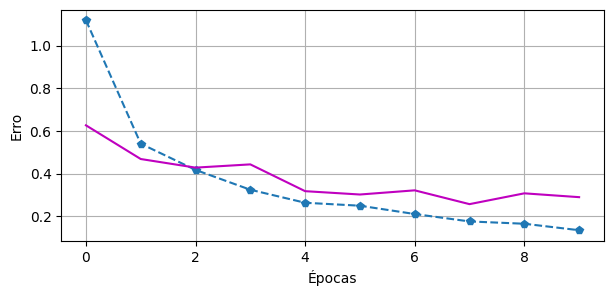

In [12]:
plt.figure(figsize=(7,3))
plt.plot(history.history['loss'], 'p--', label='Perda treino')
plt.plot(history.history['val_loss'], 'm', label ='Perda validade')
plt.ylabel('Erro')
plt.xlabel('Épocas')
plt.grid(True)

In [13]:
from sklearn.metrics import classification_report

y_true = y_test

y_pred_proba = modelo.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

print(classification_report(y_true, y_pred, target_names=CLASSES))

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
              precision    recall  f1-score   support

      Closed       0.92      0.96      0.94       109
        Open       0.96      0.92      0.94       109
     no_yawn       0.88      0.97      0.93       109
        yawn       0.97      0.87      0.92       106

    accuracy                           0.93       433
   macro avg       0.93      0.93      0.93       433
weighted avg       0.93      0.93      0.93       433



In [14]:
modelo.save('modelo_cnn_YE.h5')
modelo.save('modelo_cnn_YE.keras')

modelo.save_weights('modelo_cnn_YE.weights.h5')

In [30]:
def normalize_shap_values(shap_values, epsilon=1e-8):
    normalized_shap = []
    for val in shap_values:
        min_val = np.min(val)
        max_val = np.max(val)
        # Evitar divisão por zero
        range_val = max_val - min_val + epsilon
        normalized_shap.append((val - min_val) / range_val)  # Normalizar para o intervalo [0, 1]
    return np.array(normalized_shap)

# Implementação do SHAP
# Reduzir o número de amostras de background para economizar memória da GPU
background = X_train[np.random.choice(X_train.shape[0], 10, replace=False)]
explainer = shap.DeepExplainer(modelo, background)

# Explicar as previsões para as primeiras 10 imagens de teste
shap_values = explainer.shap_values(X_test[:10])

# Normalizar os valores SHAP para o intervalo [0, 1]
normalized_shap_values = normalize_shap_values(shap_values)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(10, 256, 256, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(20, 256, 256, 3))']
  warnings.warn(msg)


In [41]:
print("shap_values[0].shape:", shap_values[0].shape)

shap_values[0].shape: (256, 256, 3, 4)


<Figure size 1500x500 with 0 Axes>

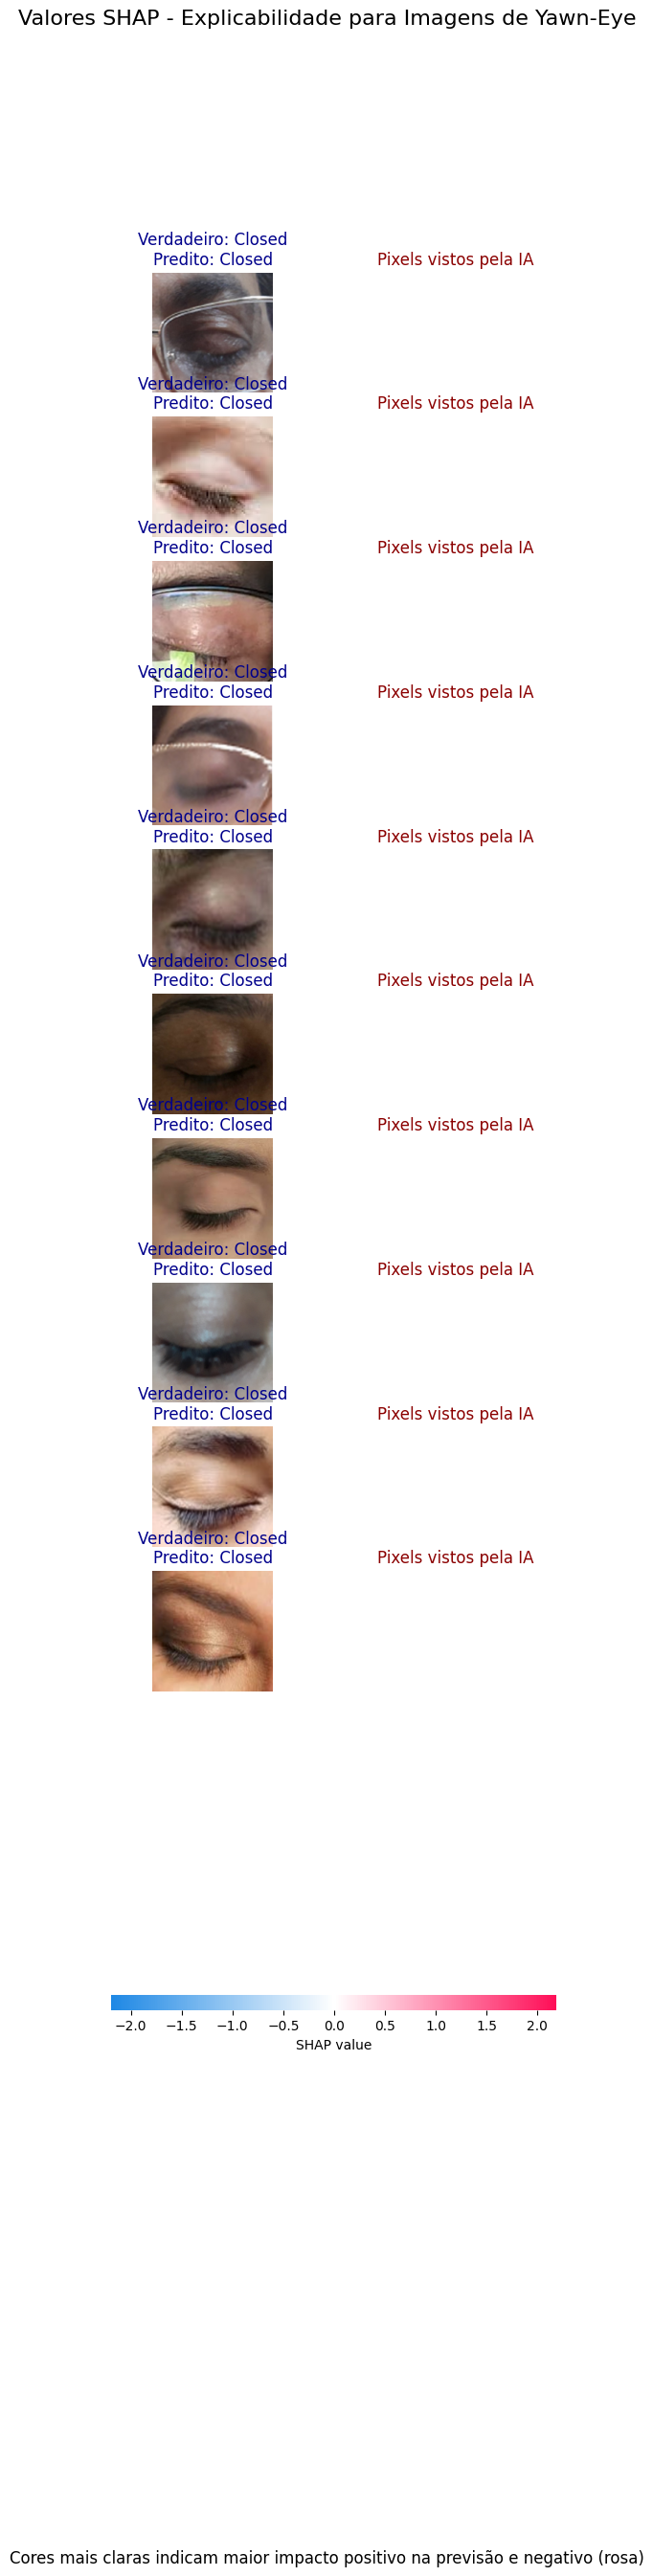

<Figure size 1500x500 with 0 Axes>

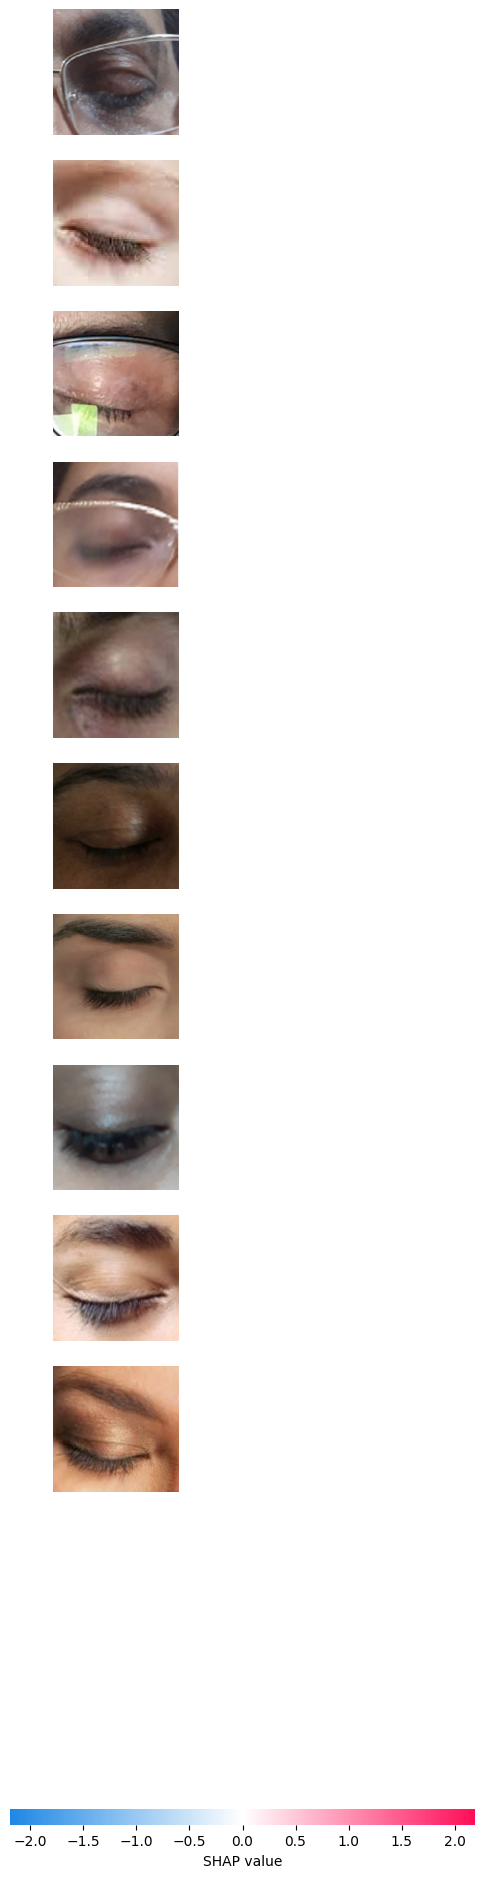

In [19]:
# Títulos personalizados para as imagens da esquerda
titles_left = [f"Verdadeiro: {CLASSES[y_test[i]]}\nPredito: {CLASSES[y_pred[i]]}" for i in range(len(normalized_shap_values))]

# Títulos para as imagens da direita
titulos_right = ["Pixels vistos pela IA" for _ in range(len(normalized_shap_values))]

# Plotar o SHAP com título em cada imagem
plt.figure(figsize=(15, 5))
shap.image_plot(normalized_shap_values, X_test[:10], show=False)

# Acessar os subplots
axes = plt.gcf().axes
for i in range(0, len(titles_left) * 2, 2):  # Subplots da esquerda
    axes[i].set_title(titles_left[i // 2], fontsize=12, color="darkblue")

for i in range(1, len(titulos_right) * 2, 2):  # Subplots da direita
    axes[i].set_title(titulos_right[i // 2], fontsize=12, color="darkred")

# Adicionar um título geral e uma legenda explicativa
plt.suptitle('Valores SHAP - Explicabilidade para Imagens de Yawn-Eye', fontsize=16)
plt.figtext(0.5, 0.01, "Cores mais claras indicam maior impacto positivo na previsão e negativo (rosa)", ha="center", fontsize=12)

# Converter imagens para uint8 para evitar warning do Matplotlib
X_test_uint8 = (X_test * 255).astype(np.uint8)

# Plot SHAP sem warnings
plt.figure(figsize=(15, 5))
shap.image_plot(
    normalized_shap_values,
    X_test_uint8[:10],
    show=False
)

plt.show()

In [18]:
print("X_test min:", X_test.min(), "max:", X_test.max())
print("SHAP min:", normalized_shap_values.min(), "max:", normalized_shap_values.max())

X_test min: 0.0 max: 1.0
SHAP min: 0.0 max: 0.9999958877736485


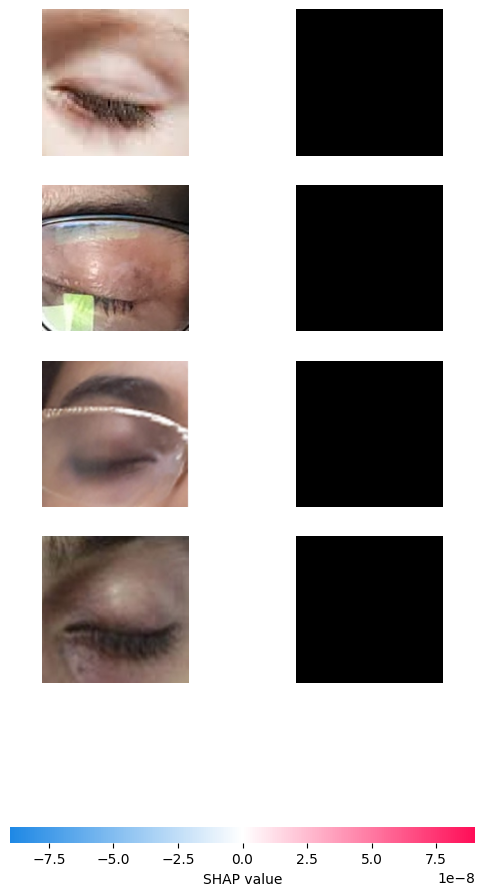

In [17]:
#background = X_train[np.random.choice(X_train.shape[0], 10, replace=False)]
#e = shap.DeepExplainer(modelo, background)

#shap_values = e.shap_values(X_test[1:5])

#shap.image_plot(shap_values, X_test[1:5])